<a href="https://colab.research.google.com/github/LaxmikantRakhade/Machine_Learning_Practicals/blob/main/Postlab(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lxmikant Rakhade(CS23128)**

**Post Lab- To implement a complete regression problem by performing data preprocessing, model building, evaluation, and result interpretation.**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score

In [4]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target_Price'] = data.target

In [5]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 MedInc          0
HouseAge        0
AveRooms        0
AveBedrms       0
Population      0
AveOccup        0
Latitude        0
Longitude       0
Target_Price    0
dtype: int64


In [6]:
X = df.drop('Target_Price', axis=1)
y = df['Target_Price']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=50, random_state=42),
    "SVR": SVR(kernel='rbf')
}


In [10]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    results.append({"Model": name, "MAE": round(mae, 4), "R2 Score": round(r2, 4)})

In [11]:
results_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(results_df)


--- Model Performance Comparison ---
               Model     MAE  R2 Score
0  Linear Regression  0.5332    0.5758
1      Decision Tree  0.5223    0.5997
2      Random Forest  0.3301    0.8039
3                SVR  0.3986    0.7276


/tmp/ipykernel_7767/1859028350.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


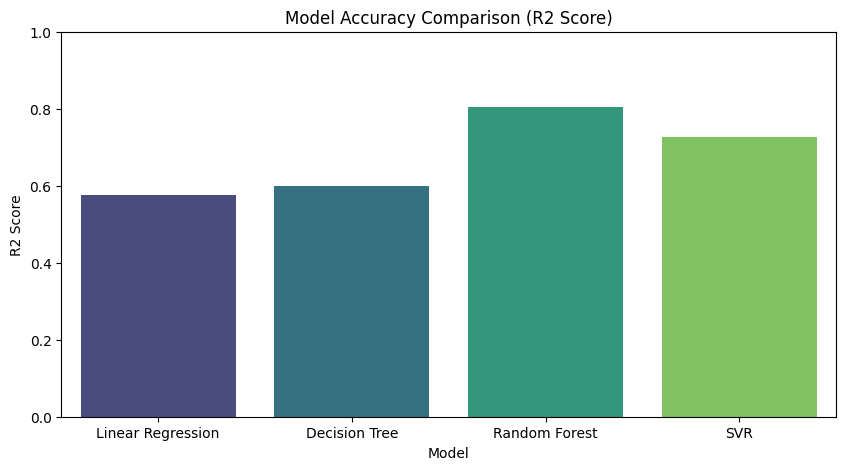

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison (R2 Score)')
plt.ylim(0, 1)
plt.show()